# Assignment - Analyzing the IMDB Top 1000 Movies

In the next few assignments, you will be working with this data set of IMDB top 1000 movies.

Source: https://www.kaggle.com/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Read the data file "imdb_top_1000.csv" to a dataframe named "imdb"
imdb = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/imdb_top_1000.csv', header=0)
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [3]:
# Describe the dataframe using the info() method.
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [4]:
# List all the column names:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

## Part 1: Data Manipulation

Redo the following to clean the data.

In [5]:
# Count the number of movies in each "Released_Year"?
# Hint: value_counts()
imdb['Released_Year'].value_counts()


,count
Released_Year,
2014,32
2004,31
2009,29
2013,28
2016,28
...,...
1920,1
1930,1
1922,1


In [6]:
# In this dataset, there is a movie with an error in "Released_Year".
# Hint: Released_Year should be a 4-digit integer but this movie's is not.
# Find this movie.
imdb[~imdb['Released_Year'].str.match(r'^\d{4}$')]


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,PG,U,140 min,"Adventure, Drama, History",7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,Bill Paxton,Kevin Bacon,Gary Sinise,269197,"173,837,933"


In [7]:
# Correct the values for the corresponding columns ("Release_Year" and "Certificate").
# You may want to look up this movie on www.imdb.com.
# Hint: You can set value for a particular set by: df.loc[row_name, column_name] = new_value
error = (
    imdb
     [~imdb['Released_Year']
      .str
      .match(r'^\d{4}$')]
    .index[0]
)
imdb.loc[error, 'Released_Year'] = '1995'
imdb.loc[error, 'Certificate'] = 'PG'


In [8]:
# Change the data type of "Released_Year" to int
imdb['Released_Year'] = (
    imdb['Released_Year']
    .astype(int)
)


In [9]:
# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
subset = (
    imdb
     [(imdb['Released_Year'] >= 2010) &
        (imdb['IMDB_Rating'] >= 8.5)]
)
subsetgross = (
    subset[['Series_Title', 'Released_Year', 'Certificate', 'Gross']]
    .sort_values(by='Gross', ascending=False)
)
subsetgross


,Series_Title,Released_Year,Certificate,Gross
19,Gisaengchung,2019,A,"53,367,844"
33,Joker,2019,A,"335,451,311"
8,Inception,2010,UA,"292,576,195"
21,Interstellar,2014,UA,"188,020,017"
35,The Intouchables,2011,UA,"13,182,281"
34,Whiplash,2014,A,"13,092,000"
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [ ]:
# Does the sorting result looks right to you? What's the problem?
# The sorting is lexicographical (alphabetical) because Gross is currently a string with commas, not a numerical type.


In [10]:
# Resolve this problem of "Gross" and convert its data type to float
# Hint: You may find this webpage useful:
# https://stackoverflow.com/questions/28986489/how-to-replace-text-in-a-column-of-a-pandas-dataframe
imdb['Gross'] = (
    imdb['Gross']
    .str
    .replace(',', '')
    .astype(float)
)



In [11]:
# Next, redo the sorting on Gross

# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
good = (
    imdb[
        (imdb['Released_Year'] >= 2010)
        & (imdb['IMDB_Rating'] >= 8.5)]
)
good[['Series_Title', 'Released_Year', 'Certificate', 'Gross']].sort_values(by='Gross', ascending=False)


,Series_Title,Released_Year,Certificate,Gross
33,Joker,2019,A,335451311.0
8,Inception,2010,UA,292576195.0
21,Interstellar,2014,UA,188020017.0
19,Gisaengchung,2019,A,53367844.0
35,The Intouchables,2011,UA,13182281.0
34,Whiplash,2014,A,13092000.0
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [12]:
# Add a new column "Runtime_min" by removing the substring ' min" in "Runtime"
# Set its data type as int
# Hint: https://stackoverflow.com/questions/36505847/substring-of-an-entire-column-in-pandas-dataframe
imdb['Runtime_min'] = (
    imdb['Runtime']
    .str
    .replace(' min', '')
    .astype(int)
)


In [13]:
# Add a new column "Age_Year" by expression: [current year] - Released_Year
imdb['Age_Year'] = 2026 - imdb['Released_Year']


In [14]:
# Add a new column "Decade" with values as 1980, 1990, 2000, 2010, 2020, etc.
imdb['Decade'] = (imdb['Released_Year'] // 10) * 10


## Part 2: Data Summarization

Done!

## Part 3: Data Visualization

Finish Parts 1 and 2 (data manipulation and summarization) before you work through this section.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

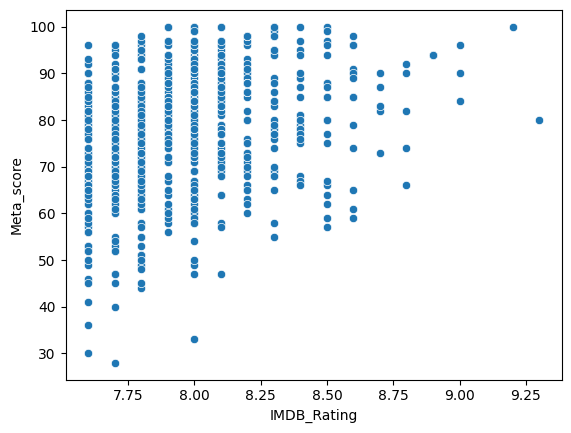

In [16]:
# Create a scatterplot of the two scores, "IMDB_Rating" and "Meta_score".
# In a sentence or two, describe what this pair of scores suggests about the movies.
sns.scatterplot(data=imdb, x='IMDB_Rating', y='Meta_score')
plt.show()
# This suggests a positive correlation; higher IMDB ratings generally map to higher Meta_scores, though variance exists.


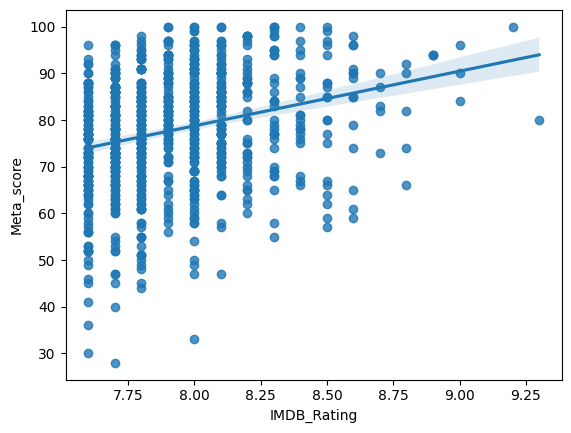

In [17]:
# Fit a trendline to show the relationship between the two scores.
# Hint: sns.regplot()
# Try a few values of the `order` argument (polynomial degree) for the trendline.
sns.regplot(data=imdb, x='IMDB_Rating', y='Meta_score', order=1)
plt.show()


In [18]:
# Do any data points in the scatterplot surprise you?
# Try to identify a few such movies.
# Movies with a very high IMDB_Rating but a relatively low Meta_score might be surprising.
imdb[(imdb['IMDB_Rating'] > 8.5) & (imdb['Meta_score'] < 70)]


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Runtime_min,Age_Year,Decade
9,https://m.media-amazon.com/images/M/MV5BMmEzNT...,Fight Club,1999,A,139 min,Drama,8.8,An insomniac office worker and a devil-may-car...,66.0,David Fincher,Brad Pitt,Edward Norton,Meat Loaf,Zach Grenier,1854740,37030102.0,139,27,1990
25,https://m.media-amazon.com/images/M/MV5BMTUxMz...,The Green Mile,1999,A,189 min,"Crime, Drama, Fantasy",8.6,The lives of guards on Death Row are affected ...,61.0,Frank Darabont,Tom Hanks,Michael Clarke Duncan,David Morse,Bonnie Hunt,1147794,136801374.0,189,27,1990
26,https://m.media-amazon.com/images/M/MV5BYmJmM2...,La vita è bella,1997,U,116 min,"Comedy, Drama, Romance",8.6,When an open-minded Jewish librarian and his s...,59.0,Roberto Benigni,Roberto Benigni,Nicoletta Braschi,Giorgio Cantarini,Giustino Durano,623629,57598247.0,116,29,1990
27,https://m.media-amazon.com/images/M/MV5BOTUwOD...,Se7en,1995,A,127 min,"Crime, Drama, Mystery",8.6,"Two detectives, a rookie and a veteran, hunt a...",65.0,David Fincher,Morgan Freeman,Brad Pitt,Kevin Spacey,Andrew Kevin Walker,1445096,100125643.0,127,31,1990


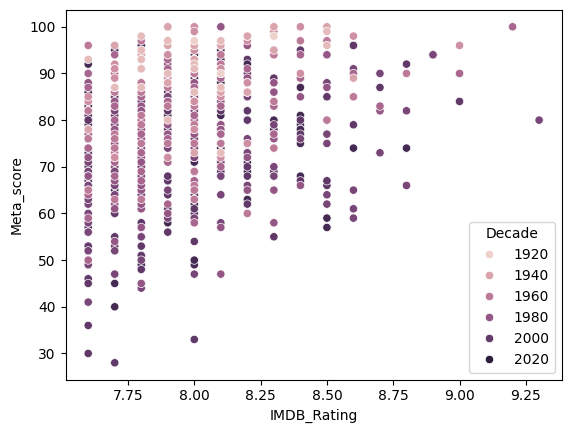

In [19]:
# In the scatterplot, use color to distinguish movies from different decades.
sns.scatterplot(data=imdb, x='IMDB_Rating', y='Meta_score', hue='Decade')
plt.show()


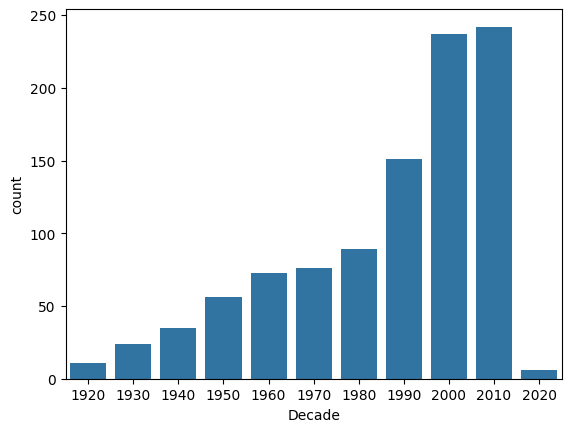

In [20]:
# Create a chart that shows how many movies fall in each decade.
sns.countplot(data=imdb, x='Decade')
plt.show()


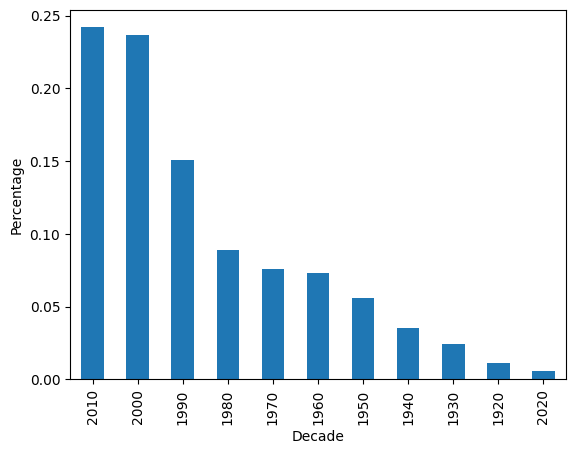

In [21]:
# Create a chart that shows the percentage of movies in each decade.
imdb['Decade'].value_counts(normalize=True).plot(kind='bar')
plt.ylabel('Percentage')
plt.show()


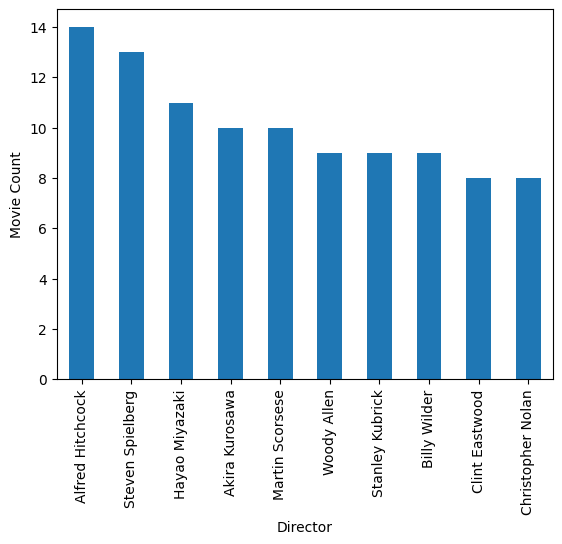

In [22]:
# Count movies by director.
# Show the top 10 directors by movie count in a bar chart.
imdb['Director'].value_counts().head(10).plot(kind='bar')
plt.ylabel('Movie Count')
plt.show()


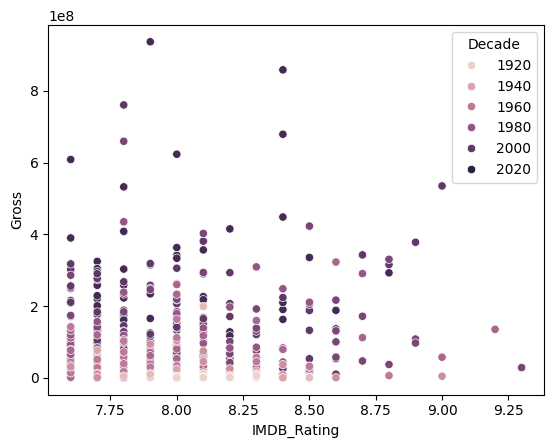

In [23]:
# Create a scatterplot of "IMDB_Rating" and "Gross".
# Use color to distinguish movies from different decades.
# Briefly interpret what the chart shows.
sns.scatterplot(data=imdb, x='IMDB_Rating', y='Gross', hue='Decade')
plt.show()
# More recent decades tend to exhibit higher absolute Gross revenues, potentially due to inflation and wider audience reach.


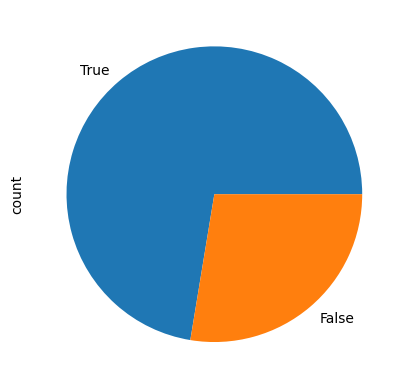

In [25]:
# Create a column named "Drama" that indicates whether a movie's genres include "Drama".
# Create a pie chart showing the share of drama vs. non-drama movies.
imdb['Drama'] = (
    imdb['Genre']
    .str.contains('Drama', na=False)
)
imdb['Drama'].value_counts().plot(kind='pie')
plt.show()


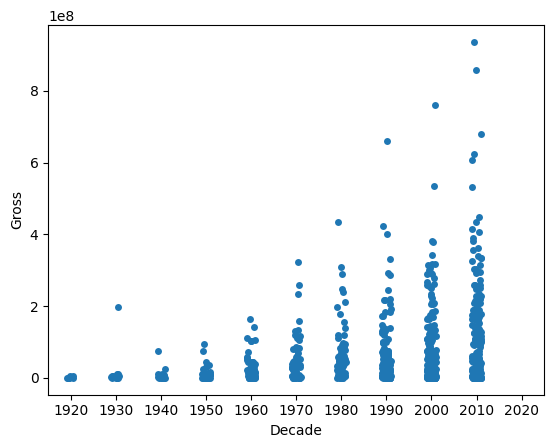

In [26]:
# Create a plot comparing gross revenue across decades.
# Using stripplot as per Phase 2 instructions for categorical vs continuous variables.
sns.stripplot(data=imdb, x='Decade', y='Gross')
plt.show()


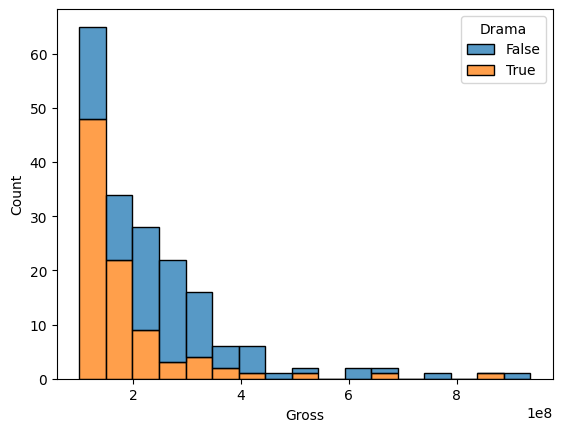

In [27]:
# For movies with gross over $100 million:
# Create a histogram of gross for drama vs. non-drama movies.
subset100 = (
    imdb
     [imdb['Gross'] > 100000000]
)
sns.histplot(data=subset100, x='Gross', hue='Drama', multiple='stack')
plt.show()


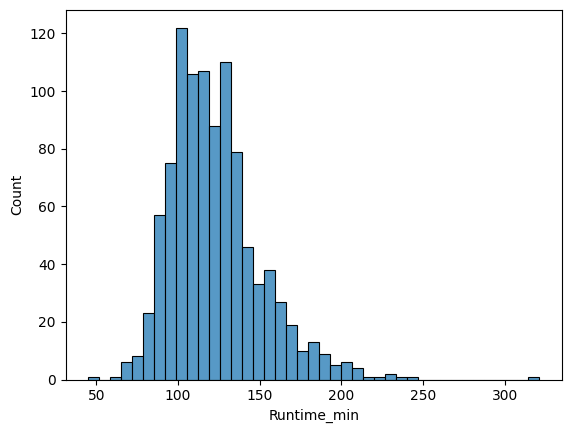

In [28]:
# Come up with two more questions about this dataset. Create one chart or figure for each.
# Question 1: What is the distribution of movie runtimes?
sns.histplot(data=imdb, x='Runtime_min')
plt.show()


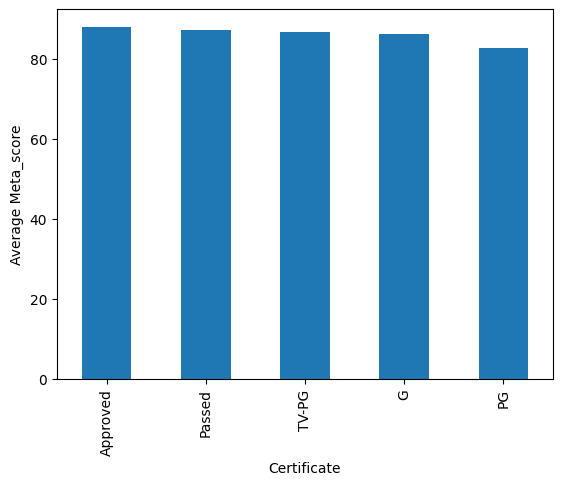

In [29]:
# Question 2: How do the top 5 certificates compare by average Meta_score?
top5 = (
    imdb.groupby('Certificate')['Meta_score']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .plot(kind='bar')
)
plt.ylabel('Average Meta_score')
plt.show()
